# Who Falls Through? Identifying Anomalous Haemoglobin Status among Non-Pregnant Women in Gabon

**Population:** Females, Gabon DHS 2019-2021 (GAIR71FL)

**Data:** IR file (Haemoglobin) merged with GE file (cluster GPS coordinates)

**Age bands:** 15-24 vs 25+


In [ ]:
###### Importing the Needed Packages #######

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import os
import glob
from pathlib import Path

from google.colab import drive
drive.mount('/content/drive')

##### creating the working director
path1 = '/content/drive/My Drive/MyProjects/AnaemiaStudy/ResidualWork'
os.chdir(path1)
os.getcwd()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/My Drive/MyProjects/AnaemiaStudy/ResidualWork'

In [ ]:
#######   Locate and inspect the GPS (GE) shapefile and IR data file  ########

# Update this to match your actual folder name inside AnaemiaStudy
gabon_folder = Path(path1) / "DHSDATAGABON/Main_data" ## my data is here

if not gabon_folder.exists():
    raise FileNotFoundError(f"Folder does not exist: {gabon_folder}")

print("Contents of Gabon data folder:")
for f in sorted(gabon_folder.iterdir()):
    print(" -", f.name)

shp_files = list(gabon_folder.glob("*.shp"))
dta_files = list(gabon_folder.glob("*IR*.DTA")) + list(gabon_folder.glob("*IR*.dta"))

print()
print("Shapefile(s) found:", [f.name for f in shp_files])
print("IR .DTA file(s) found:", [f.name for f in dta_files])



Contents of Gabon data folder:
 - GAGE71FL.cpg
 - GAGE71FL.dbf
 - GAGE71FL.prj
 - GAGE71FL.sbn
 - GAGE71FL.sbx
 - GAGE71FL.shp
 - GAGE71FL.shp.xml
 - GAGE71FL.shx
 - GAIR71FL.DTA

Shapefile(s) found: ['GAGE71FL.shp']
IR .DTA file(s) found: ['GAIR71FL.DTA']


In [ ]:
####### Load the IR file (women's individual recode) - only needed columns #######

ir_path = dta_files[0]  # adjust index if multiple matches

target_vars = ['caseid', 'v001', 'v002', 'v003', 'v005', 'v012',
               'v024', 'v025', 'v106', 'v190', 'v213', 'v456',
               'v201', 'v404', 'v463a', 'v222']

df_ir = pd.read_stata(ir_path, convert_categoricals=False, columns=target_vars)

print("IR file loaded:", df_ir.shape)
print("v012 (age) range:", df_ir['v012'].min(), "-", df_ir['v012'].max())
print()

####### Inspect v456 (haemoglobin) before any cleaning #######

print("v456 (haemoglobin, raw) summary stats:")
print(df_ir['v456'].describe())
print()
print("Missing (NaN) count:", df_ir['v456'].isna().sum())  # count only, not yet removed
print("Count of sentinel value 999 (if present):", (df_ir['v456'] == 999).sum())
print("Max value (check for sentinel contamination):", df_ir['v456'].max())
print()

####### Inspect v213 (pregnancy status) before filtering #######

print("v213 (currently pregnant) value counts:")
print(df_ir['v213'].value_counts(dropna=False).sort_index())
print()

####### Inspect v222 (months since last birth) before filtering #######
# DHS sentinel codes for this variable: 97/98/99 typically indicate not applicable/don't know/missing
# (respondent has never given birth, or data missing) - these should NOT be treated as '<3 months'

print("v222 (months since last birth) summary stats:")
print(df_ir['v222'].describe())
print()
print("v222 value counts at the low and high extremes (check for sentinel codes):")
print(df_ir['v222'].value_counts(dropna=False).sort_index().tail(10))


IR file loaded: (11043, 16)
v012 (age) range: 15 - 64

v456 (haemoglobin, raw) summary stats:
count    6005.000000
mean      112.687594
std        15.872692
min        37.000000
25%       104.000000
50%       114.000000
75%       123.000000
max       188.000000
Name: v456, dtype: float64

Missing (NaN) count: 5038
Count of sentinel value 999 (if present): 0
Max value (check for sentinel contamination): 188.0

v213 (currently pregnant) value counts:
v213
0.0    8783
1.0     724
NaN    1536
Name: count, dtype: int64

v222 (months since last birth) summary stats:
count    6916.000000
mean       63.007663
std        70.294491
min         0.000000
25%        15.000000
50%        37.000000
75%        84.000000
max       429.000000
Name: v222, dtype: float64

v222 value counts at the low and high extremes (check for sentinel codes):
v222
386.0       1
387.0       2
388.0       1
390.0       1
391.0       1
396.0       2
400.0       1
409.0       1
429.0       1
NaN      4127
Name: count, dtyp

In [ ]:
####### Clean sentinel values and Constructing core variables #######

# v456 (haemoglobin): stored as g/dL x 10; no sentinel contamination found (checked earlier)
df_ir['haemoglobin_gdl'] = df_ir['v456'] / 10

# Age band split
df_ir['age_band'] = np.where(df_ir['v012'] <= 24, '15-24', '25+')

# ---- Clean v222 (months since last birth): treat DHS sentinel codes (97/98/99) as NaN,
# i.e. "not applicable" (never given birth) rather than a real recency value ----
df_ir['months_since_birth'] = df_ir['v222'].replace([97, 98, 99], np.nan)

# Count pregnant women before excluding them
n_pregnant = (df_ir['v213'] == 1).sum()

# Count postpartum (<3 months since last birth) women, among those NOT already pregnant,
# before excluding them - avoids double counting women who are both currently pregnant
# and recently postpartum (e.g. a new pregnancy shortly after a prior birth)
n_postpartum_lt3mo = ((df_ir['v213'] != 1) & (df_ir['months_since_birth'] < 3)).sum()

# ---- Apply exclusions: pregnant OR recently postpartum (<3 months), then require valid Hb ----
exclude_mask = (df_ir['v213'] == 1) | (df_ir['months_since_birth'] < 3)
df_clean = df_ir[~exclude_mask].copy()
df_clean = df_clean.dropna(subset=['haemoglobin_gdl']).copy()

print("Rows before any exclusion:", len(df_ir))
print("Number of pregnant women removed (v213 == 1):", n_pregnant)
print("Number of additional postpartum women removed (<3 months since last birth):", n_postpartum_lt3mo)
print("Rows after excluding pregnant AND recently postpartum women:", len(df_ir[~exclude_mask]))
print("Rows with valid haemoglobin AND not pregnant/recently postpartum:", len(df_clean))
print()
print("Age band distribution (final analytic sample):")
print(df_clean['age_band'].value_counts())
print()
print("Haemoglobin (g/dL) stats (final analytic sample):")
print(df_clean['haemoglobin_gdl'].describe())


Rows before any exclusion: 11043
Number of pregnant women removed (v213 == 1): 724
Number of additional postpartum women removed (<3 months since last birth): 325
Rows after excluding pregnant AND recently postpartum women: 9994
Rows with valid haemoglobin AND not pregnant/recently postpartum: 5328

Age band distribution (final analytic sample):
age_band
25+      3360
15-24    1968
Name: count, dtype: int64

Haemoglobin (g/dL) stats (final analytic sample):
count    5328.000000
mean       11.342943
std         1.575733
min         3.700000
25%        10.500000
50%        11.500000
75%        12.400000
max        18.800000
Name: haemoglobin_gdl, dtype: float64


In [ ]:
###### Renaming and Coding the other variables #######

# ---- Urban/Rural (v025): 1 = Urban, 2 = Rural ----
df_clean['residence'] = df_clean['v025'].map({1: 'Urban', 2: 'Rural'})

# ---- Education level (v106): 0=None, 1=Primary, 2=Secondary, 3=Higher ----
df_clean['education'] = df_clean['v106'].map({
    0: 'None',
    1: 'Primary',
    2: 'Secondary',
    3: 'Higher'
})

# ---- Wealth quintile (v190): 1=Poorest ... 5=Richest ----
df_clean['wealth_quintile'] = df_clean['v190'].map({
    1: 'Poorest',
    2: 'Poorer',
    3: 'Middle',
    4: 'Richer',
    5: 'Richest'
})

# ---- Parity (v201): total children ever born - keep as continuous count ----
df_clean['parity'] = df_clean['v201']

# ---- Breastfeeding (v404): 0 = No, 1 = Yes ----
df_clean['breastfeeding'] = df_clean['v404'].map({0: 'No', 1: 'Yes'})

# ---- Smoking - cigarettes (v463a): 0 = No, 1 = Yes ----
df_clean['smokes_cigarettes'] = df_clean['v463a'].map({0: 'No', 1: 'Yes'})

# ---- Region (v024): categorical ----
df_clean['region'] = df_clean['v024'].astype('category')

# ---- Age, numeric (for use alongside age_band) ----
df_clean['age_numeric'] = df_clean['v012']

# ---- DHS sample weight - stored with 6 implied decimal places ----
df_clean['wt'] = df_clean['v005'] / 1_000_000

# Note: cluster altitude (v040) was tested and deliberately excluded. haemoglobin_gdl (v456)
# is DHS's altitude-and-smoking-adjusted Hb value, but checking the adjustment amount
# (raw v453 minus adjusted v456) showed it was ~0 across the full altitude range in this
# sample (Gabon's cluster altitudes: 3m-772m, below the ~1000m threshold where the WHO/CDC
# formula meaningfully adjusts). Altitude nonetheless showed strong feature importance in
# earlier regression tests, suggesting a real but unadjusted-for geographic/ecological
# relationship with Hb - interesting, but conceptually separate from the sociodemographic
# 'falls through' framing of this analysis, so it is left out of the modelling variables here.

# ---- Quick check: confirm no unexpected NaNs introduced by mapping ----
recoded_vars = ['residence', 'education', 'wealth_quintile', 'parity', 'breastfeeding',
                'smokes_cigarettes', 'region', 'age_numeric', 'wt']

print("Missingness check after recoding:")
for v in recoded_vars:
    print(f"  {v}: {df_clean[v].isna().sum()} missing")
print()

print("Value counts for each recoded categorical variable:\n")
for v in ['residence', 'education', 'wealth_quintile', 'breastfeeding', 'smokes_cigarettes', 'region']:
    print(f"--- {v} ---")
    print(df_clean[v].value_counts(dropna=False))
    print()

print("--- parity (continuous) ---")
print(df_clean['parity'].describe())
print()

# ---- Final covariate + outcome dataframe for modelling ----
model_vars = ['age_band', 'age_numeric', 'residence', 'education', 'wealth_quintile',
              'parity', 'breastfeeding', 'smokes_cigarettes', 'region',
              'wt', 'haemoglobin_gdl']

df_model = df_clean[model_vars].copy()

print("Final modelling dataframe shape:", df_model.shape)
df_model.head()


Missingness check after recoding:
  residence: 0 missing
  education: 0 missing
  wealth_quintile: 0 missing
  parity: 0 missing
  breastfeeding: 0 missing
  smokes_cigarettes: 0 missing
  region: 0 missing
  age_numeric: 0 missing
  wt: 0 missing

Value counts for each recoded categorical variable:

--- residence ---
residence
Urban    3838
Rural    1490
Name: count, dtype: int64

--- education ---
education
Secondary    3454
Primary      1147
Higher        412
None          315
Name: count, dtype: int64

--- wealth_quintile ---
wealth_quintile
Poorest    2029
Poorer     1076
Middle      853
Richer      762
Richest     608
Name: count, dtype: int64

--- breastfeeding ---
breastfeeding
No     4689
Yes     639
Name: count, dtype: int64

--- smokes_cigarettes ---
smokes_cigarettes
No     5179
Yes     149
Name: count, dtype: int64

--- region ---
region
1     588
11    567
4     558
2     521
10    504
9     503
8     453
5     451
3     419
6     390
7     374
Name: count, dtype: int64



,age_band,age_numeric,residence,education,wealth_quintile,parity,breastfeeding,smokes_cigarettes,region,wt,haemoglobin_gdl
4,25+,30,Urban,Secondary,Poorest,6.0,No,No,6,0.591106,9.5
8,25+,47,Urban,Secondary,Richer,2.0,No,No,6,0.591106,12.7
9,25+,34,Urban,Secondary,Richer,1.0,No,No,6,0.591106,12.3
11,25+,48,Urban,None,Poorest,1.0,No,No,6,0.591106,11.3
13,25+,47,Urban,Secondary,Poorest,9.0,No,No,6,0.591106,12.5


# Final descriptive analysis and region labels

The original DHS data-reading and preparation code above is retained. The analysis below uses the original DHS variables and adds the 11 Gabon DHS region names to `V024`.

The descriptive analysis is stratified into women aged **15–24 years** and **25 years and older**.

- Continuous variables: **mean (SD)**
- Categorical variables: **number (%)**
- Weighted and unweighted results are displayed **side-by-side**
- DHS sampling weights are used for the weighted estimates
- Region is reported using the original 11-category Gabon DHS regional classification


## Cell 8 — Apply the Gabon DHS V024 region labels

In [ ]:
# ============================================================
# CELL 8 — GABON DHS REGION LABELS
# ============================================================

# Gabon DHS V024 regional classification.
# These are the 11 regions used in the dataset.

region_labels = {
    1: "Libreville",
    2: "Port-Gentil",
    3: "Estuaire (without Libreville)",
    4: "Haut-Ogooué",
    5: "Moyen-Ogooué",
    6: "Ngounié",
    7: "Nyanga",
    8: "Ogooué-Ivindo",
    9: "Ogooué-Lolo",
    10: "Ogooué-Maritime (without Port-Gentil)",
    11: "Woleu-Ntem"
}

# Preserve the original V024 numeric code.
df_clean["region_code"] = pd.to_numeric(
    df_clean["v024"],
    errors="coerce"
)

# Add the readable DHS region name.
df_clean["region"] = (
    df_clean["region_code"]
    .map(region_labels)
)

print("=" * 100)
print("GABON DHS V024 REGION LABELS")
print("=" * 100)

region_check = (
    df_clean["region_code"]
    .value_counts()
    .sort_index()
    .rename_axis("V024 code")
    .reset_index(name="N")
)

region_check["Region"] = (
    region_check["V024 code"]
    .map(region_labels)
)

region_check = region_check[
    ["V024 code", "Region", "N"]
]

display(region_check)


GABON DHS V024 REGION LABELS


,V024 code,Region,N
0,1,Libreville,588
1,2,Port-Gentil,521
2,3,Estuaire (without Libreville),419
3,4,Haut-Ogooué,558
4,5,Moyen-Ogooué,451
5,6,Ngounié,390
6,7,Nyanga,374
7,8,Ogooué-Ivindo,453
8,9,Ogooué-Lolo,503
9,10,Ogooué-Maritime (without Port-Gentil),504


## Cell 9 — Create the final 15–64 analytic sample

In [ ]:
# ============================================================
# CELL 9 — FINAL ANALYTIC SAMPLE
# ============================================================

df_analysis = df_clean.loc[
    df_clean["age_numeric"].between(
        15,
        64,
        inclusive="both"
    )
].copy()

analysis_vars = [
    "age_numeric",
    "parity",
    "haemoglobin_gdl",
    "residence",
    "education",
    "wealth_quintile",
    "breastfeeding",
    "smokes_cigarettes",
    "region",
    "wt"
]

df_analysis = df_analysis.dropna(
    subset=analysis_vars
).copy()

print(
    "Final analytic sample:",
    f"{len(df_analysis):,}"
)

print(
    "Age range:",
    df_analysis["age_numeric"].min(),
    "-",
    df_analysis["age_numeric"].max()
)


Final analytic sample: 5,328
Age range: 15 - 49


## Cell 10 — Create the two age groups

In [ ]:
# ============================================================
# CELL 10 — AGE GROUPS
# ============================================================

df_analysis["age_band"] = np.where(
    df_analysis["age_numeric"].between(
        15,
        24,
        inclusive="both"
    ),
    "15-24",
    "25+"
)

df_analysis["age_band"] = pd.Categorical(
    df_analysis["age_band"],
    categories=["15-24", "25+"],
    ordered=True
)

display(
    df_analysis["age_band"]
    .value_counts()
    .sort_index()
)


,count
age_band,
15-24,1968
25+,3360


## Cell 11 — Descriptive-analysis functions

In [ ]:
# ============================================================
# CELL 11 — DESCRIPTIVE FUNCTIONS
# ============================================================

def unweighted_mean_sd(data, variable):

    x = pd.to_numeric(
        data[variable],
        errors="coerce"
    ).dropna()

    if len(x) == 0:
        return "NA"

    return (
        f"{x.mean():.2f} "
        f"({x.std():.2f})"
    )


def weighted_mean_sd(
    data,
    variable,
    weight="wt"
):

    temp = data[
        [variable, weight]
    ].dropna().copy()

    if (
        len(temp) == 0
        or temp[weight].sum() <= 0
    ):
        return "NA"

    x = temp[variable].astype(float).to_numpy()
    w = temp[weight].astype(float).to_numpy()

    mean = np.average(
        x,
        weights=w
    )

    variance = np.average(
        (x - mean) ** 2,
        weights=w
    )

    sd = np.sqrt(variance)

    return (
        f"{mean:.2f} "
        f"({sd:.2f})"
    )


def unweighted_n_pct(
    data,
    variable,
    category
):

    x = data[variable].dropna()

    if len(x) == 0:
        return "NA"

    n = int(
        (x == category).sum()
    )

    pct = (
        n /
        len(x)
    ) * 100

    return (
        f"{n} "
        f"({pct:.1f}%)"
    )


def weighted_n_pct(
    data,
    variable,
    category,
    weight="wt"
):

    temp = data[
        [variable, weight]
    ].dropna().copy()

    if (
        len(temp) == 0
        or temp[weight].sum() <= 0
    ):
        return "NA"

    n = int(
        (temp[variable] == category).sum()
    )

    weighted_n = temp.loc[
        temp[variable] == category,
        weight
    ].sum()

    weighted_pct = (
        weighted_n /
        temp[weight].sum()
    ) * 100

    return (
        f"{n} "
        f"({weighted_pct:.1f}%)"
    )



## Cell 12 — Generate weighted and unweighted descriptive analysis

In [ ]:
# ============================================================
# CELL 12 — DESCRIPTIVE ANALYSIS
# ============================================================

continuous_descriptives = [
    ("age_numeric", "Age"),
    ("parity", "Parity"),
    ("haemoglobin_gdl", "Haemoglobin (g/dL)")
]

categorical_descriptives = [
    ("residence", "Residence"),
    ("education", "Education"),
    ("wealth_quintile", "Wealth quintile"),
    ("breastfeeding", "Breastfeeding"),
    ("smokes_cigarettes", "Cigarette smoking"),
    ("region", "Region")
]

rows = []


# ------------------------------------------------------------
# Continuous variables
# ------------------------------------------------------------

for variable, label in continuous_descriptives:

    for age_group in ["15-24", "25+"]:

        subset = df_analysis.loc[
            df_analysis["age_band"].astype(str)
            == age_group
        ]

        rows.append({
            "Variable": label,
            "Category": "",
            "Age group": age_group,
            "Unweighted": unweighted_mean_sd(
                subset,
                variable
            ),
            "Weighted": weighted_mean_sd(
                subset,
                variable
            )
        })


# ------------------------------------------------------------
# Categorical variables
# ------------------------------------------------------------

for variable, label in categorical_descriptives:

    if variable == "region":

        categories = sorted(
            df_analysis["region_code"]
            .dropna()
            .unique()
            .tolist()
        )

        category_pairs = [
            (
                code,
                region_labels.get(
                    int(code),
                    f"Region {int(code)}"
                )
            )
            for code in categories
        ]

    else:

        categories = (
            df_analysis[variable]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

        categories = sorted(categories)

        category_pairs = [
            (cat, cat)
            for cat in categories
        ]


    for category_value, category_label in category_pairs:

        for age_group in ["15-24", "25+"]:

            subset = df_analysis.loc[
                df_analysis["age_band"].astype(str)
                == age_group
            ]

            if variable == "region":

                unweighted = unweighted_n_pct(
                    subset.assign(
                        region_display=
                        subset["region_code"]
                    ),
                    "region_display",
                    category_value
                )

                weighted = weighted_n_pct(
                    subset.assign(
                        region_display=
                        subset["region_code"]
                    ),
                    "region_display",
                    category_value
                )

            else:

                unweighted = unweighted_n_pct(
                    subset,
                    variable,
                    category_value
                )

                weighted = weighted_n_pct(
                    subset,
                    variable,
                    category_value
                )


            rows.append({
                "Variable": label,
                "Category": category_label,
                "Age group": age_group,
                "Unweighted": unweighted,
                "Weighted": weighted
            })


descriptives_long = pd.DataFrame(rows)


# ------------------------------------------------------------
# Side-by-side format
# ------------------------------------------------------------

descriptive_side_by_side = (
    descriptives_long
    .pivot_table(
        index=[
            "Variable",
            "Category"
        ],
        columns="Age group",
        values=[
            "Unweighted",
            "Weighted"
        ],
        aggfunc="first"
    )
    .reset_index()
)


descriptive_side_by_side.columns = [
    (
        f"{col[1]} {col[0]}"
        if isinstance(col, tuple)
        and col[1]
        else str(col[0])
    )
    for col in descriptive_side_by_side.columns
]


desired_order = [
    "Variable",
    "Category",
    "15-24 Unweighted",
    "15-24 Weighted",
    "25+ Unweighted",
    "25+ Weighted"
]

descriptive_side_by_side = (
    descriptive_side_by_side[
        [
            c
            for c in desired_order
            if c in descriptive_side_by_side.columns
        ]
    ]
)

print(
    "Descriptive analysis created."
)

display(
    descriptive_side_by_side
)

### Export to
descriptive_side_by_side.to_csv(
    "Gabon_escriptive_side_by_side_Analysis.csv",
    index=False
)


Descriptive analysis created.


,Variable,Category,15-24 Unweighted,15-24 Weighted,25+ Unweighted,25+ Weighted
0,Age,,19.14 (2.92),19.58 (2.94),36.06 (7.23),35.38 (7.09)
1,Breastfeeding,No,1721 (87.4%),1721 (90.3%),2968 (88.3%),2968 (89.5%)
2,Breastfeeding,Yes,247 (12.6%),247 (9.7%),392 (11.7%),392 (10.5%)
3,Cigarette smoking,No,1929 (98.0%),1929 (97.4%),3250 (96.7%),3250 (96.3%)
4,Cigarette smoking,Yes,39 (2.0%),39 (2.6%),110 (3.3%),110 (3.7%)
5,Education,Higher,70 (3.6%),70 (8.7%),342 (10.2%),342 (17.6%)
6,Education,None,54 (2.7%),54 (4.1%),261 (7.8%),261 (7.5%)
7,Education,Primary,301 (15.3%),301 (9.6%),846 (25.2%),846 (14.9%)
8,Education,Secondary,1543 (78.4%),1543 (77.6%),1911 (56.9%),1911 (60.0%)
9,Haemoglobin (g/dL),,11.26 (1.50),11.19 (1.49),11.39 (1.61),11.32 (1.67)


## Cell 13 — Region-only descriptive check

In [ ]:
# ============================================================
# CELL 13 — REGION DESCRIPTIVE CHECK
# ============================================================

region_descriptives = []

for age_group in ["15-24", "25+"]:

    subset = df_analysis.loc[
        df_analysis["age_band"].astype(str)
        == age_group
    ]

    for code_value in range(1, 12):

        region_name = region_labels[
            code_value
        ]

        region_descriptives.append({
            "Age group": age_group,
            "V024 code": code_value,
            "Region": region_name,
            "Unweighted N (%)":
                unweighted_n_pct(
                    subset.assign(
                        region_display=
                        subset["region_code"]
                    ),
                    "region_display",
                    code_value
                ),
            "Weighted N (%)":
                weighted_n_pct(
                    subset.assign(
                        region_display=
                        subset["region_code"]
                    ),
                    "region_display",
                    code_value
                )
        })


region_descriptives = pd.DataFrame(
    region_descriptives
)

display(region_descriptives)


,Age group,V024 code,Region,Unweighted N (%),Weighted N (%)
0,15-24,1,Libreville,205 (10.4%),205 (44.1%)
1,15-24,2,Port-Gentil,169 (8.6%),169 (10.1%)
2,15-24,3,Estuaire (without Libreville),145 (7.4%),145 (12.1%)
3,15-24,4,Haut-Ogooué,214 (10.9%),214 (10.3%)
4,15-24,5,Moyen-Ogooué,190 (9.7%),190 (3.9%)
5,15-24,6,Ngounié,138 (7.0%),138 (4.2%)
6,15-24,7,Nyanga,160 (8.1%),160 (2.3%)
7,15-24,8,Ogooué-Ivindo,170 (8.6%),170 (2.2%)
8,15-24,9,Ogooué-Lolo,203 (10.3%),203 (2.8%)
9,15-24,10,Ogooué-Maritime (without Port-Gentil),183 (9.3%),183 (1.3%)


## Cell 14 — Export descriptive analysis to Excel

In [ ]:
# ============================================================
# CELL 14 — EXPORT DESCRIPTIVE ANALYSIS TO EXCEL
# ============================================================

from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter


excel_output = "Gabon_DHS_Descriptive_Analysis_Weighted_Unweighted.xlsx"


with pd.ExcelWriter(
    excel_output,
    engine="openpyxl"
) as writer:

    descriptive_side_by_side.to_excel(
        writer,
        sheet_name="Descriptives",
        index=False
    )

    region_descriptives.to_excel(
        writer,
        sheet_name="Region Descriptives",
        index=False
    )

    region_check.to_excel(
        writer,
        sheet_name="Region Codes",
        index=False
    )


# Format workbook.
wb = load_workbook(
    excel_output
)

for ws in wb.worksheets:

    for cell in ws[1]:

        cell.font = Font(
            bold=True
        )

        cell.alignment = Alignment(
            horizontal="center",
            vertical="center"
        )

    ws.freeze_panes = "A2"

    if ws.max_row > 1:
        ws.auto_filter.ref = ws.dimensions

    for column in ws.columns:

        max_length = 0

        letter = get_column_letter(
            column[0].column
        )

        for cell in column:

            if cell.value is not None:

                max_length = max(
                    max_length,
                    len(str(cell.value))
                )

        ws.column_dimensions[
            letter
        ].width = min(
            max_length + 2,
            45
        )

wb.save(
    excel_output
)

print(
    "Excel file created:",
    excel_output
)


Excel file created: Gabon_DHS_Descriptive_Analysis_Weighted_Unweighted.xlsx


## Cell 15 — Final descriptive-analysis check

The Excel workbook contains the main descriptive table with weighted and unweighted results side-by-side, plus separate region tables using the 11 Gabon DHS V024 region names.


In [ ]:
# ============================================================
# CELL 15 — FINAL CHECK
# ============================================================

print("=" * 110)
print("DESCRIPTIVE ANALYSIS COMPLETE")
print("=" * 110)
print()

print(
    "Final analytic sample:",
    f"{len(df_analysis):,}"
)

print(
    "Age 15-24:",
    f"{(df_analysis['age_band'] == '15-24').sum():,}"
)

print(
    "Age 25+:",
    f"{(df_analysis['age_band'] == '25+').sum():,}"
)

print()
print(
    "Region labels used:"
)

for code_value, name in region_labels.items():
    print(
        f"  V024 {code_value}: {name}"
    )

print()
print(
    "Excel workbook:",
    excel_output
)


DESCRIPTIVE ANALYSIS COMPLETE

Final analytic sample: 5,328
Age 15-24: 1,968
Age 25+: 3,360

Region labels used:
  V024 1: Libreville
  V024 2: Port-Gentil
  V024 3: Estuaire (without Libreville)
  V024 4: Haut-Ogooué
  V024 5: Moyen-Ogooué
  V024 6: Ngounié
  V024 7: Nyanga
  V024 8: Ogooué-Ivindo
  V024 9: Ogooué-Lolo
  V024 10: Ogooué-Maritime (without Port-Gentil)
  V024 11: Woleu-Ntem

Excel workbook: Gabon_DHS_Descriptive_Analysis_Weighted_Unweighted.xlsx


## Cell 16 — Feature preparation for Isolation Forest

In [ ]:
# ============================================================
# CELL 16 — FEATURE PREPARATION FOR ISOLATION FOREST
# ============================================================

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# ---- Continuous variables: standardised (zero mean, unit variance) ----
continuous_features = ['age_numeric', 'parity', 'haemoglobin_gdl']

# ---- Categorical variables: one-hot encoded, one reference category dropped per variable ----
categorical_features = ['residence', 'education', 'wealth_quintile',
                         'breastfeeding', 'smokes_cigarettes', 'region']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

# Fit the preprocessor on the full analytic sample so that category encoding is consistent
# across the overall-sample model and the two age-stratified models below.
X_full = preprocessor.fit_transform(df_analysis[continuous_features + categorical_features])

# Recover feature names for reference (useful for later interpretation, e.g. permutation importance)
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = continuous_features + list(cat_feature_names)

print(f"Encoded feature matrix shape: {X_full.shape}")
print(f"Total encoded features: {len(all_feature_names)}")
print()
print("Feature names:")
for f in all_feature_names:
    print(" -", f)


Encoded feature matrix shape: (5328, 23)
Total encoded features: 23

Feature names:
 - age_numeric
 - parity
 - haemoglobin_gdl
 - residence_Urban
 - education_None
 - education_Primary
 - education_Secondary
 - wealth_quintile_Poorer
 - wealth_quintile_Poorest
 - wealth_quintile_Richer
 - wealth_quintile_Richest
 - breastfeeding_Yes
 - smokes_cigarettes_Yes
 - region_Haut-Ogooué
 - region_Libreville
 - region_Moyen-Ogooué
 - region_Ngounié
 - region_Nyanga
 - region_Ogooué-Ivindo
 - region_Ogooué-Lolo
 - region_Ogooué-Maritime (without Port-Gentil)
 - region_Port-Gentil
 - region_Woleu-Ntem


## Cell 17 — Fit Isolation Forest: overall sample and two age-stratified models

In [ ]:
# ============================================================
# CELL 17 — ISOLATION FOREST: OVERALL + AGE-STRATIFIED MODELS
# ============================================================

from sklearn.ensemble import IsolationForest

RANDOM_SEED = 42       # fixed seed for reproducibility
N_ESTIMATORS = 500     # ensemble size
CONTAMINATION = 0.05   # conventional exploratory threshold - flags ~5% as anomalous

def fit_isolation_forest(X, sample_weight=None, random_state=RANDOM_SEED):
    """Fit an Isolation Forest with the pre-specified hyperparameters and return
    the fitted model, continuous anomaly scores, and binary anomaly flags."""
    model = IsolationForest(
        n_estimators=N_ESTIMATORS,
        contamination=CONTAMINATION,
        random_state=random_state,
        n_jobs=-1
    )
    model.fit(X, sample_weight=sample_weight)

    # CONVENTION: higher anomaly_score = MORE anomalous, matching the original
    # Liu, Ting & Zhou (2008) iForest formulation (short average path length ->
    # high anomaly score). scikit-learn's score_samples() natively returns the
    # opposite (higher = more normal), so we negate it here to adopt the
    # conventional 'high = anomalous' framing used throughout this study.
    anomaly_score = -model.score_samples(X)

    # predict(): -1 = anomaly, 1 = normal -> convert to boolean is_anomaly
    is_anomaly = model.predict(X) == -1

    return model, anomaly_score, is_anomaly


# ---- Model 1: overall sample (all females, irrespective of age) ----
weights_full = df_analysis['wt'].to_numpy()

iforest_overall, score_overall, flag_overall = fit_isolation_forest(
    X_full, sample_weight=weights_full
)

df_analysis['anomaly_score'] = score_overall
df_analysis['is_anomaly'] = flag_overall

print("Overall-sample model fitted.")
print(f"Anomalous: {flag_overall.sum()} / {len(flag_overall)} "
      f"({100*flag_overall.mean():.1f}%)")
print()


# ---- Models 2 and 3: separate models fitted within each age band ----
# (uses the SAME encoded feature matrix/columns as the overall model, subset by age band,
# so that anomaly scores remain comparable against a common feature representation)

df_analysis['anomaly_score_agestrat'] = np.nan
df_analysis['is_anomaly_agestrat'] = np.nan

age_band_models = {}

for band in ['15-24', '25+']:
    band_mask = (df_analysis['age_band'].astype(str) == band).to_numpy()
    X_band = X_full[band_mask]
    weights_band = df_analysis.loc[band_mask, 'wt'].to_numpy()

    model_band, score_band, flag_band = fit_isolation_forest(
        X_band, sample_weight=weights_band
    )

    age_band_models[band] = model_band

    df_analysis.loc[band_mask, 'anomaly_score_agestrat'] = score_band
    df_analysis.loc[band_mask, 'is_anomaly_agestrat'] = flag_band

    print(f"Age band {band} model fitted.")
    print(f"  N = {band_mask.sum()}")
    print(f"  Anomalous: {flag_band.sum()} / {band_mask.sum()} "
          f"({100*flag_band.mean():.1f}%)")

df_analysis['is_anomaly_agestrat'] = df_analysis['is_anomaly_agestrat'].astype(bool)


Overall-sample model fitted.
Anomalous: 267 / 5328 (5.0%)



/tmp/ipykernel_10466/1420006493.py:69: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False False False ... False False False]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_analysis.loc[band_mask, 'is_anomaly_agestrat'] = flag_band


Age band 15-24 model fitted.
  N = 1968
  Anomalous: 99 / 1968 (5.0%)
Age band 25+ model fitted.
  N = 3360
  Anomalous: 168 / 3360 (5.0%)


## Cell 17b — Lancet-style anomaly plots: overall sample and age-stratified

In [ ]:
####### Anomaly score vs haemoglobin plots (facet grid, boxed panel style) #######
####### NOTE: anomaly_score here follows the convention HIGH = MORE anomalous #######

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix'

COLOR_NORMAL = '#8C8C8C'
COLOR_ANOMALY = '#B22222'
COLOR_MEDIAN = '#2A6F97'
COLOR_WHO = '#333333'
WHO_THRESHOLD = 12.0

panels = [
    ('Overall sample',
     df_analysis, 'anomaly_score', 'is_anomaly'),
    ('Aged 15\u201324 years',
     df_analysis[df_analysis['age_band'].astype(str) == '15-24'],
     'anomaly_score_agestrat', 'is_anomaly_agestrat'),
    ('Aged 25+ years',
     df_analysis[df_analysis['age_band'].astype(str) == '25+'],
     'anomaly_score_agestrat', 'is_anomaly_agestrat'),
]

fig, axes = plt.subplots(1, 3, figsize=(19, 6), dpi=150, sharey=True, sharex=True)

for ax, (label, data, score_col, flag_col) in zip(axes, panels):
    subset = data.dropna(subset=[score_col, flag_col])

    normal = subset[~subset[flag_col].astype(bool)]
    anomaly = subset[subset[flag_col].astype(bool)]
    pct_anomaly = 100 * len(anomaly) / len(subset)

    ax.scatter(normal['haemoglobin_gdl'], normal[score_col],
               c=COLOR_NORMAL, alpha=0.5, s=15, linewidths=0,
               label=f'Normal (n={len(normal):,})', zorder=2)

    ax.scatter(anomaly['haemoglobin_gdl'], anomaly[score_col],
               c=COLOR_ANOMALY, alpha=0.85, s=28, linewidths=0.4, edgecolors='white',
               label=f'Anomaly (n={len(anomaly):,}, {pct_anomaly:.1f}%)', zorder=3)

    median_hb = subset['haemoglobin_gdl'].median()

    ax.axvline(median_hb, color=COLOR_MEDIAN, linestyle='-', linewidth=1.0, alpha=0.85, zorder=1)
    ax.axvline(WHO_THRESHOLD, color=COLOR_WHO, linestyle='--', linewidth=1.0, alpha=0.85, zorder=1)

    ymin, ymax = ax.get_ylim()
    yrange = ymax - ymin

    if median_hb <= WHO_THRESHOLD:
        ax.text(median_hb - 0.15, ymax - 0.06 * yrange, 'Median',
                fontsize=9, color=COLOR_MEDIAN, style='italic', fontweight='bold',
                va='top', ha='right')
        ax.text(WHO_THRESHOLD + 0.15, ymax - 0.015 * yrange, 'WHO threshold',
                fontsize=9, color=COLOR_WHO, style='italic', fontweight='bold',
                va='top', ha='left')
    else:
        ax.text(WHO_THRESHOLD - 0.15, ymax - 0.06 * yrange, 'WHO threshold',
                fontsize=9, color=COLOR_WHO, style='italic', fontweight='bold',
                va='top', ha='right')
        ax.text(median_hb + 0.15, ymax - 0.015 * yrange, 'Median',
                fontsize=9, color=COLOR_MEDIAN, style='italic', fontweight='bold',
                va='top', ha='left')

    ax.set_xlabel('Haemoglobin, g/dL', fontsize=11, labelpad=8)

    legend = ax.legend(loc='lower right', frameon=False, fontsize=8.5, handletextpad=0.5)

    # ---- Boxed panel style: keep ALL FOUR spines visible (full rectangle border) ----
    ax.grid(False)
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(0.9)
    ax.tick_params(colors='black', labelsize=9.5, direction='out', length=4)

    # ---- Header strip: shaded box above the panel, labelling it (FacetGrid column-title style) ----
    ax.annotate(
        label,
        xy=(0.5, 1), xycoords='axes fraction',
        xytext=(0, 6), textcoords='offset points',
        ha='center', va='bottom', fontsize=11.5, fontweight='bold',
        bbox=dict(boxstyle='square,pad=0.4', facecolor='#EAEAEA',
                   edgecolor='black', linewidth=0.9)
    )

axes[0].set_ylabel('Isolation forest anomaly score', fontsize=12, labelpad=8)

plt.tight_layout()
plt.subplots_adjust(top=0.88, wspace=0.08)
plt.savefig('anomaly_score_vs_haemoglobin_facetgrid_boxed.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

print("Saved: anomaly_score_vs_haemoglobin_facetgrid_boxed.png")
print()
for label, data, score_col, flag_col in panels:
    subset = data.dropna(subset=[score_col, flag_col])
    n_anomaly = subset[flag_col].astype(bool).sum()
    print(f"{label}: n={len(subset):,}, anomalous={n_anomaly} "
          f"({100*n_anomaly/len(subset):.1f}%)")


## Cell 18a — Concentration of anomalous haemoglobin–sociodemographic, behavioural and reproductive health profiles within population groups (overall, 15–24 years, 25+ years)

In [ ]:
# ============================================================
# CELL 18a — CONCENTRATION OF ANOMALOUS PROFILES BY POPULATION GROUP
# ============================================================
# Assesses whether anomalous haemoglobin-sociodemographic, behavioural and reproductive
# health profiles were concentrated within particular population groups, separately for
# the overall sample and each age band. Parity is categorised (0, 1, 2-4, 5+) so it can
# be treated consistently alongside the other categorical variables.

# ---- Categorise parity: 0, 1, 2-4, 5+ ----
df_analysis['parity_cat'] = pd.cut(
    df_analysis['parity'],
    bins=[-0.1, 0, 1, 4, float('inf')],
    labels=['0', '1', '2-4', '5+']
)

subgroup_vars = ['residence', 'education', 'wealth_quintile', 'breastfeeding',
                  'smokes_cigarettes', 'region', 'parity_cat']

analysis_groups = [
    ('Overall sample', df_analysis, 'is_anomaly'),
    ('Aged 15-24 years',
     df_analysis[df_analysis['age_band'].astype(str) == '15-24'],
     'is_anomaly_agestrat'),
    ('Aged 25+ years',
     df_analysis[df_analysis['age_band'].astype(str) == '25+'],
     'is_anomaly_agestrat'),
]

hb_by_anomaly_rows = []
concentration_rows = []

for group_label, group_data, flag_col in analysis_groups:
    subset = group_data.dropna(subset=[flag_col]).copy()
    subset[flag_col] = subset[flag_col].astype(bool)

    n_anomalous_total = subset[flag_col].sum()
    n_overall_total = len(subset)

    print(f"{group_label}: anomalous = {n_anomalous_total} / {n_overall_total} "
          f"({100*n_anomalous_total/n_overall_total:.1f}%)")

    # ---- Haemoglobin by anomaly status ----
    hb_stats = subset.groupby(flag_col)['haemoglobin_gdl'].agg(['mean', 'std', 'count']).round(2)
    for is_anom, row in hb_stats.iterrows():
        hb_by_anomaly_rows.append({
            'Group': group_label,
            'Anomalous': 'Yes' if is_anom else 'No',
            'Mean Hb (g/dL)': row['mean'],
            'SD Hb (g/dL)': row['std'],
            'N': int(row['count'])
        })

    # ---- Where anomalies concentrate: n (%) of anomalies vs n (%) of overall sample ----
    for var in subgroup_vars:
        anomaly_counts = subset[subset[flag_col]][var].value_counts()
        overall_counts = subset[var].value_counts()

        for cat in overall_counts.index:
            n_anom = int(anomaly_counts.get(cat, 0))
            n_overall = int(overall_counts.get(cat, 0))
            pct_anom = 100 * n_anom / n_anomalous_total if n_anomalous_total > 0 else 0.0
            pct_overall = 100 * n_overall / n_overall_total if n_overall_total > 0 else 0.0

            concentration_rows.append({
                'Group': group_label,
                'Variable': var,
                'Category': cat,
                'Anomalies, n (%)': f"{n_anom} ({pct_anom:.1f}%)",
                'Overall sample, n (%)': f"{n_overall} ({pct_overall:.1f}%)",
                'Difference (pp)': round(pct_anom - pct_overall, 1)
            })

hb_by_anomaly_table = pd.DataFrame(hb_by_anomaly_rows)
concentration_table = pd.DataFrame(concentration_rows)

print()
print("Haemoglobin by anomaly status (all groups):")
display(hb_by_anomaly_table)
print()
print("Concentration of anomalies within population groups (all groups):")
display(concentration_table)


####### Heatmap: concentration of anomalies (Difference, pp) by variable/category and group #######

import seaborn as sns
import matplotlib.pyplot as plt

# Preserve first-seen (Variable, Category) order rather than alphabetical, for readability
row_order = (
    concentration_table[['Variable', 'Category']]
    .drop_duplicates()
    .apply(lambda r: f"{r['Variable']}: {r['Category']}", axis=1)
    .tolist()
)

concentration_table['Row label'] = (
    concentration_table['Variable'] + ': ' + concentration_table['Category'].astype(str)
)

heatmap_data_18a = concentration_table.pivot_table(
    index='Row label', columns='Group', values='Difference (pp)'
).reindex(row_order)

heatmap_data_18a = heatmap_data_18a[['Overall sample', 'Aged 15-24 years', 'Aged 25+ years']]

fig, ax = plt.subplots(figsize=(8, 0.4 * len(heatmap_data_18a) + 2), dpi=150)
sns.heatmap(
    heatmap_data_18a, annot=True, fmt='.1f', cmap='RdBu_r', center=0,
    linewidths=0.5, linecolor='white', cbar_kws={'label': 'Difference (pp)'},
    ax=ax
)
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('Gabon_18a_Concentration_Heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("Saved: Gabon_18a_Concentration_Heatmap.png")


## Cell 18b — Concentration of anomalous haemoglobin–sociodemographic, behavioural and reproductive health profiles within population groups (overall, 15–24 years, 25+ years)

In [ ]:
# ============================================================
# CELL 18b — CONCENTRATION OF ANOMALOUS PROFILES BY POPULATION GROUP (SIDE BY SIDE)
# ============================================================
# Same variable set as Cell 18a, merged into one side-by-side comparison table across
# the overall sample and both age bands, with the exact column naming convention:
# '{Group}, N (%)', '{Group} - Anomalous, N (%)', '{Group} - Difference (pp)'

characterisation_vars = ['residence', 'education', 'wealth_quintile', 'breastfeeding',
                          'smokes_cigarettes', 'region', 'parity_cat']

group_tables = {}

for group_label, group_data, flag_col in analysis_groups:
    subset = group_data.dropna(subset=[flag_col]).copy()
    subset[flag_col] = subset[flag_col].astype(bool)

    n_overall_total = len(subset)
    n_anomalous_total = subset[flag_col].sum()

    rows = []
    for var in characterisation_vars:
        categories = sorted(subset[var].dropna().unique().tolist(), key=str)
        for cat in categories:
            n_overall = int((subset[var] == cat).sum())
            n_anom = int((subset.loc[subset[flag_col], var] == cat).sum())
            pct_overall = 100 * n_overall / n_overall_total if n_overall_total > 0 else 0.0
            pct_anom = 100 * n_anom / n_anomalous_total if n_anomalous_total > 0 else 0.0

            rows.append({
                'Variable': var,
                'Category': cat,
                f'{group_label}, N (%)': f"{n_overall} ({pct_overall:.1f}%)",
                f'{group_label} - Anomalous, N (%)': f"{n_anom} ({pct_anom:.1f}%)",
                f'{group_label} - Difference (pp)': round(pct_anom - pct_overall, 1)
            })

    group_tables[group_label] = pd.DataFrame(rows).set_index(['Variable', 'Category'])


####### Merge the three group tables side by side on (Variable, Category) #######
# (each group's columns already carry their final names, so a simple join preserves them
# exactly, without the generic 'Group - column' flattening used previously)

side_by_side = (
    group_tables['Overall sample']
    .join(group_tables['Aged 15-24 years'], how='outer')
    .join(group_tables['Aged 25+ years'], how='outer')
    .reset_index()
)

print("Concentration of anomalous profiles - side by side by group:")
display(side_by_side)


####### Export to CSV #######

side_by_side.to_csv("Gabon_18b_Characterisation_SideBySide.csv", index=False)
print("\nSaved: Gabon_18b_Characterisation_SideBySide.csv")


####### Heatmap: concentration of anomalies (Difference, pp) by variable/category and group #######

import seaborn as sns
import matplotlib.pyplot as plt

diff_cols = ['Overall sample - Difference (pp)',
             'Aged 15-24 years - Difference (pp)',
             'Aged 25+ years - Difference (pp)']

heatmap_data_18b = side_by_side.copy()
heatmap_data_18b['Row label'] = (
    heatmap_data_18b['Variable'] + ': ' + heatmap_data_18b['Category'].astype(str)
)
heatmap_data_18b = heatmap_data_18b.set_index('Row label')[diff_cols]
heatmap_data_18b.columns = ['Overall sample', 'Aged 15-24 years', 'Aged 25+ years']

fig, ax = plt.subplots(figsize=(8, 0.4 * len(heatmap_data_18b) + 2), dpi=150)
sns.heatmap(
    heatmap_data_18b, annot=True, fmt='.1f', cmap='RdBu_r', center=0,
    linewidths=0.5, linecolor='white', cbar_kws={'label': 'Difference (pp)'},
    ax=ax
)
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('Gabon_18b_Characterisation_Heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("Saved: Gabon_18b_Characterisation_Heatmap.png")


## Cell 19 — The 'falls-through' subgroup

Sample median haemoglobin: 11.50 g/dL

Higher-SES females (richer/richest + secondary/higher education): 1206
  Of these, flagged anomalous: 13 (1.1%)
  Meeting full 'falls-through' definition (anomalous AND Hb < median): 4 (0.3% of higher-SES females)

'Falls-through' subgroup, by age band:


,n_falls_through
age_band,
15-24,2
25+,2



Profile of the 'falls-through' subgroup:


,age_band,age_numeric,residence,education,wealth_quintile,parity,breastfeeding,smokes_cigarettes,region,haemoglobin_gdl,anomaly_score
3237,15-24,21,Rural,Higher,Richest,1.0,Yes,No,Woleu-Ntem,11.1,0.536212
5624,25+,30,Rural,Higher,Richer,3.0,No,Yes,Ogooué-Maritime (without Port-Gentil),11.0,0.549425
5962,15-24,18,Urban,Secondary,Richer,2.0,Yes,Yes,Moyen-Ogooué,10.7,0.542743
6313,25+,35,Urban,Higher,Richer,3.0,Yes,No,Ogooué-Lolo,7.9,0.534393


Saved:
  Gabon_19_FallsThrough_Summary.csv
  Gabon_19_FallsThrough_ByAgeBand.csv
  Gabon_19_FallsThrough_Profiles.csv


/tmp/ipykernel_68466/4246387151.py:202: UserWarning: Glyph 772 (\N{COMBINING MACRON}) missing from font(s) Liberation Serif.
  plt.tight_layout()
/tmp/ipykernel_68466/4246387151.py:204: UserWarning: Glyph 772 (\N{COMBINING MACRON}) missing from font(s) Liberation Serif.
  plt.savefig('Gabon_19_Haemoglobin_vs_Wealth_FacetGrid.png', dpi=300,
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 772 (\N{COMBINING MACRON}) missing from font(s) Liberation Serif.
  fig.canvas.print_figure(bytes_io, **kw)


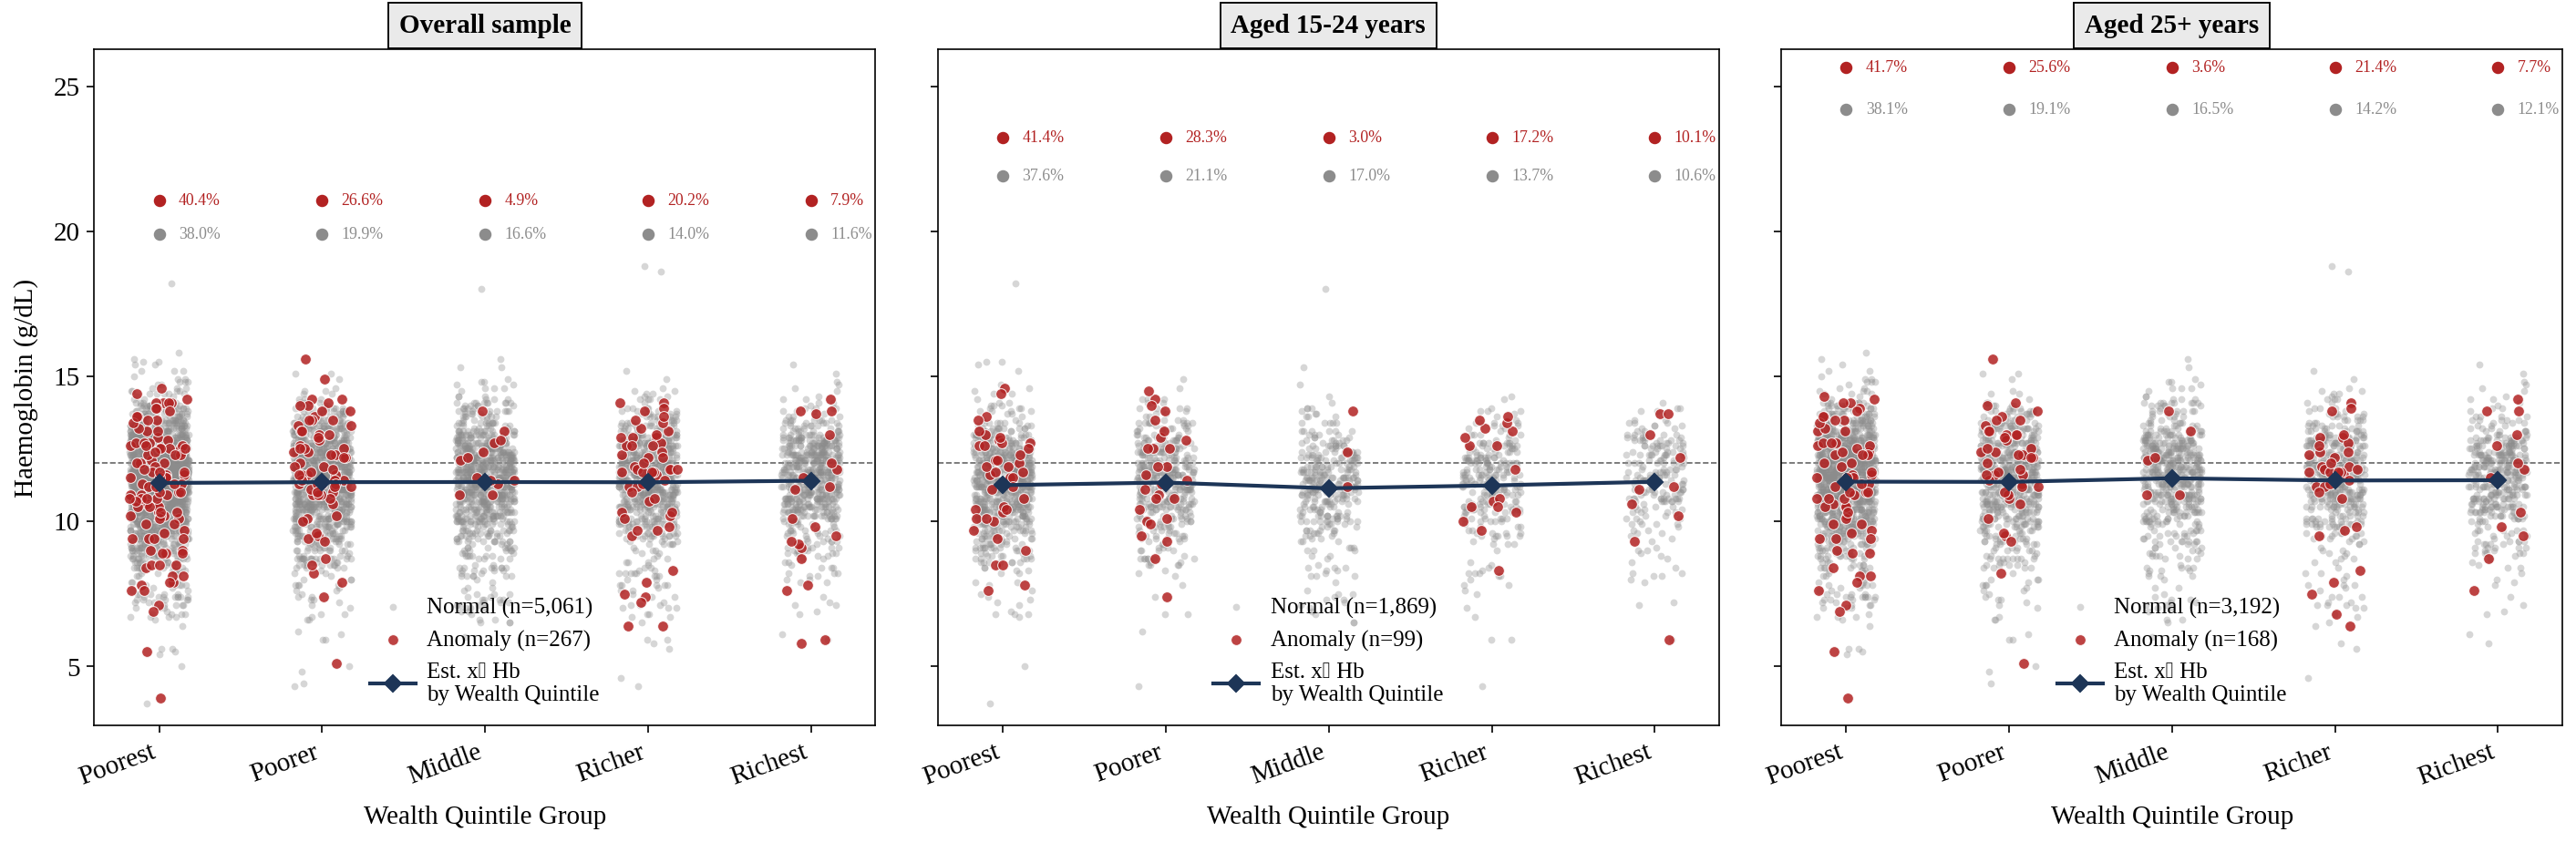

Saved: Gabon_19_Haemoglobin_vs_Wealth_FacetGrid.png


In [50]:
# ============================================================
# CELL 19 — 'FALLS-THROUGH' SUBGROUP
# ============================================================

# Higher socioeconomic status: richer/richest wealth quintile AND secondary/higher education
df_analysis['higher_ses'] = (
    df_analysis['wealth_quintile'].isin(['Richer', 'Richest'])
    & df_analysis['education'].isin(['Secondary', 'Higher'])
)

median_hb = df_analysis['haemoglobin_gdl'].median()

# 'Falls through': higher-SES AND flagged anomalous AND haemoglobin below the sample median
df_analysis['falls_through'] = (
    df_analysis['higher_ses']
    & df_analysis['is_anomaly']
    & (df_analysis['haemoglobin_gdl'] < median_hb)
)

n_higher_ses = df_analysis['higher_ses'].sum()
n_higher_ses_anomalous = (df_analysis['higher_ses'] & df_analysis['is_anomaly']).sum()
n_falls_through = df_analysis['falls_through'].sum()

print(f"Sample median haemoglobin: {median_hb:.2f} g/dL")
print()
print(f"Higher-SES females (richer/richest + secondary/higher education): {n_higher_ses}")
print(f"  Of these, flagged anomalous: {n_higher_ses_anomalous} "
      f"({100*n_higher_ses_anomalous/n_higher_ses:.1f}%)")
print(f"  Meeting full 'falls-through' definition (anomalous AND Hb < median): {n_falls_through} "
      f"({100*n_falls_through/n_higher_ses:.1f}% of higher-SES females)")
print()

print("'Falls-through' subgroup, by age band:")
display(
    df_analysis[df_analysis['falls_through']]
    .groupby(df_analysis['age_band'].astype(str))
    .size()
    .rename('n_falls_through')
)
print()

print("Profile of the 'falls-through' subgroup:")
falls_through_cols = ['age_band', 'age_numeric', 'residence', 'education', 'wealth_quintile',
                      'parity', 'breastfeeding', 'smokes_cigarettes', 'region', 'haemoglobin_gdl',
                      'anomaly_score']
display(df_analysis.loc[df_analysis['falls_through'], falls_through_cols])


####### Export 'falls-through' results to CSV #######

falls_through_summary = pd.DataFrame([{
    'Median haemoglobin (g/dL)': round(median_hb, 2),
    'Higher-SES females (n)': int(n_higher_ses),
    'Higher-SES AND anomalous (n)': int(n_higher_ses_anomalous),
    'Higher-SES AND anomalous (%)': round(100 * n_higher_ses_anomalous / n_higher_ses, 1),
    "'Falls-through' (n)": int(n_falls_through),
    "'Falls-through' (% of higher-SES)": round(100 * n_falls_through / n_higher_ses, 1),
}])
falls_through_summary.to_csv('Gabon_19_FallsThrough_Summary.csv', index=False)

falls_through_by_age = (
    df_analysis[df_analysis['falls_through']]
    .groupby(df_analysis['age_band'].astype(str))
    .size()
    .rename('n_falls_through')
    .reset_index()
)
falls_through_by_age.to_csv('Gabon_19_FallsThrough_ByAgeBand.csv', index=False)

falls_through_profile = df_analysis.loc[df_analysis['falls_through'], falls_through_cols]
falls_through_profile.to_csv('Gabon_19_FallsThrough_Profiles.csv', index=False)

print("Saved:")
print("  Gabon_19_FallsThrough_Summary.csv")
print("  Gabon_19_FallsThrough_ByAgeBand.csv")
print("  Gabon_19_FallsThrough_Profiles.csv")


####### Concept plot (facet grid): haemoglobin vs wealth quintile, overall + age-stratified #######
####### Shows anomalies as deviations from the EXPECTED sociodemographic-haemoglobin pattern #######

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix'

COLOR_NORMAL = '#8C8C8C'
COLOR_ANOMALY = '#B22222'
COLOR_LINE = '#1D3557'
WHO_THRESHOLD = 12.0

wealth_order = {'Poorest': 1, 'Poorer': 2, 'Middle': 3, 'Richer': 4, 'Richest': 5}
df_analysis['wealth_numeric'] = df_analysis['wealth_quintile'].map(wealth_order)

rng = np.random.default_rng(42)
df_analysis['wealth_jittered'] = df_analysis['wealth_numeric'] + rng.uniform(
    -0.18, 0.18, size=len(df_analysis)
)

wealth_panels = [
    ('Overall sample', df_analysis, 'is_anomaly'),
    ('Aged 15-24 years',
     df_analysis[df_analysis['age_band'].astype(str) == '15-24'],
     'is_anomaly_agestrat'),
    ('Aged 25+ years',
     df_analysis[df_analysis['age_band'].astype(str) == '25+'],
     'is_anomaly_agestrat'),
]

fig, axes = plt.subplots(1, 3, figsize=(19, 6.5), dpi=150, sharey=True)

for ax, (label, data, flag_col) in zip(axes, wealth_panels):
    subset = data.dropna(subset=[flag_col]).copy()
    subset[flag_col] = subset[flag_col].astype(bool)

    normal = subset[~subset[flag_col]]
    anomaly = subset[subset[flag_col]]

    ax.scatter(normal['wealth_jittered'], normal['haemoglobin_gdl'],
               c=COLOR_NORMAL, alpha=0.35, s=14, linewidths=0,
               label=f'Normal (n={len(normal):,})', zorder=2)

    ax.scatter(anomaly['wealth_jittered'], anomaly['haemoglobin_gdl'],
               c=COLOR_ANOMALY, alpha=0.85, s=32, linewidths=0.5, edgecolors='white',
               label=f'Anomaly (n={len(anomaly):,})', zorder=3)

    # ---- Per-quintile distribution markers: % of Normal and % of Anomaly falling in
    # each wealth quintile, shown as a small coloured dot + percentage above each column ----

    n_normal_total = len(normal)
    n_anomaly_total = len(anomaly)

    # Extend the y-axis upward to make room for the two annotation rows
    ymin, ymax = ax.get_ylim()
    yrange = ymax - ymin
    ax.set_ylim(ymin, ymax + 0.12 * yrange)

    y_anomaly_row = ymax + 0.09 * yrange   # upper row: anomaly %
    y_normal_row = ymax + 0.02 * yrange    # lower row: normal %

    for q in [1, 2, 3, 4, 5]:
        n_normal_q = (normal['wealth_numeric'] == q).sum()
        n_anomaly_q = (anomaly['wealth_numeric'] == q).sum()

        pct_normal_q = 100 * n_normal_q / n_normal_total if n_normal_total > 0 else 0.0
        pct_anomaly_q = 100 * n_anomaly_q / n_anomaly_total if n_anomaly_total > 0 else 0.0

        # Anomaly row: red dot + percentage
        ax.scatter(q, y_anomaly_row, c=COLOR_ANOMALY, s=30, zorder=5, clip_on=False)
        ax.text(q + 0.12, y_anomaly_row, f"{pct_anomaly_q:.1f}%", fontsize=8.5,
                color=COLOR_ANOMALY, va='center', ha='left', clip_on=False)

        # Normal row: grey dot + percentage
        ax.scatter(q, y_normal_row, c=COLOR_NORMAL, s=30, zorder=5, clip_on=False)
        ax.text(q + 0.12, y_normal_row, f"{pct_normal_q:.1f}%", fontsize=8.5,
                color=COLOR_NORMAL, va='center', ha='left', clip_on=False)

    expected_by_quintile = (
        subset.groupby('wealth_numeric')['haemoglobin_gdl']
        .mean()
        .reindex([1, 2, 3, 4, 5])
    )

    ax.plot(expected_by_quintile.index, expected_by_quintile.values,
            color=COLOR_LINE, linewidth=2, marker='D', markersize=6, zorder=4,
            label='Est. x̄ Hb\nby Wealth Quintile')

    ax.axhline(WHO_THRESHOLD, color='black', linestyle='--', linewidth=0.8, alpha=0.6, zorder=1)

    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xticklabels(['Poorest', 'Poorer', 'Middle', 'Richer', 'Richest'],
                        fontsize=14, rotation=20, ha='right')
    ax.set_xlabel('Wealth Quintile Group', fontsize=14, labelpad=8)

    # Header strip: shaded box above the panel (matches the anomaly score facet grid style)
    ax.annotate(
        label,
        xy=(0.5, 1), xycoords='axes fraction',
        xytext=(0, 6), textcoords='offset points',
        ha='center', va='bottom', fontsize=14, fontweight='bold',
        bbox=dict(boxstyle='square,pad=0.4', facecolor='#EAEAEA',
                   edgecolor='black', linewidth=0.9)
    )

    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(0.8)
    ax.tick_params(colors='black', labelsize=14, direction='out', length=4)

    # Legend on EVERY panel, positioned bottom-centre (i.e. under the 'Middle'
    # wealth quintile column, since the five categories are evenly spaced and
    # centred), with no frame/box around it. Each panel needs its own legend since
    # each has its own n counts (Normal/Anomaly) and its own mean-Hb line.
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, 0.0),
              frameon=False, fontsize=12, handletextpad=0.5)

axes[0].set_ylabel('Haemoglobin (g/dL)', fontsize=14, labelpad=8)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.savefig('Gabon_19_Haemoglobin_vs_Wealth_FacetGrid.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

print("Saved: Gabon_19_Haemoglobin_vs_Wealth_FacetGrid.png")


## Cell 20 — Characterisation of anomalies against the overall sample

In [ ]:
# ============================================================
# CELL 20 — CHARACTERISATION OF ANOMALIES VS OVERALL SAMPLE
# ============================================================

characterisation_vars = ['residence', 'education', 'wealth_quintile',
                          'breastfeeding', 'smokes_cigarettes']

comparison_rows = []

for var in characterisation_vars:
    categories = sorted(df_analysis[var].dropna().unique().tolist())
    for cat in categories:
        overall_pct = 100 * (df_analysis[var] == cat).mean()
        anomaly_pct = 100 * (
            df_analysis.loc[df_analysis['is_anomaly'], var] == cat
        ).mean()

        comparison_rows.append({
            'Variable': var,
            'Category': cat,
            'Overall sample (%)': round(overall_pct, 1),
            'Anomalous group (%)': round(anomaly_pct, 1),
            'Difference (pp)': round(anomaly_pct - overall_pct, 1)
        })

anomaly_characterisation = pd.DataFrame(comparison_rows)

print("Characterisation of anomalous females vs overall sample:")
display(anomaly_characterisation)

anomaly_characterisation.to_csv('Gabon_Anomaly_Characterisation.csv', index=False)
print("\nSaved: Gabon_Anomaly_Characterisation.csv")


Characterisation of anomalous females vs overall sample:


,Variable,Category,Overall sample (%),Anomalous group (%),Difference (pp)
0,residence,Rural,28.0,38.2,10.2
1,residence,Urban,72.0,61.8,-10.2
2,education,Higher,7.7,3.4,-4.4
3,education,None,5.9,40.4,34.5
4,education,Primary,21.5,47.2,25.7
5,education,Secondary,64.8,9.0,-55.8
6,wealth_quintile,Middle,16.0,4.9,-11.1
7,wealth_quintile,Poorer,20.2,26.6,6.4
8,wealth_quintile,Poorest,38.1,40.4,2.4
9,wealth_quintile,Richer,14.3,20.2,5.9



Saved: Gabon_Anomaly_Characterisation.csv


In [ ]:
# ============================================================
# CELL 19c — POPULATION PROFILE OF ANOMALOUS FEMALES WITHIN EACH
# WEALTH (RICHER/RICHEST) x EDUCATION (SECONDARY/HIGHER) CELL, BY GROUP
# ============================================================
# IMPORTANT: this table describes the characteristics of ANOMALOUS females only,
# within each wealth x education x age-group cell - not the characteristics of the
# whole wealth x education population. Every percentage below is calculated among
# anomalous females specifically (i.e. denominators are the anomalous subgroup size
# in that cell, not the cell's total population).

ses_wealth_levels = ['Richer', 'Richest']
ses_education_levels = ['Secondary', 'Higher']
breakdown_vars = ['residence', 'region', 'smokes_cigarettes', 'parity_cat', 'breastfeeding']

ses_groups = [
    ('Overall sample', df_analysis, 'is_anomaly'),
    ('Aged 15-24 years',
     df_analysis[df_analysis['age_band'].astype(str) == '15-24'],
     'is_anomaly_agestrat'),
    ('Aged 25+ years',
     df_analysis[df_analysis['age_band'].astype(str) == '25+'],
     'is_anomaly_agestrat'),
]

# ---- Row index: a summary row, then every (Variable, Category) pair ----
row_index_pairs = [('Summary', 'Anomalous females, N (% of cell)')]
for var in breakdown_vars:
    categories = sorted(df_analysis[var].dropna().unique().tolist(), key=str)
    for cat in categories:
        row_index_pairs.append((var, str(cat)))

# ---- Build one column per (Group, Wealth, Education) cell ----
column_data = {}

for group_label, group_data, flag_col in ses_groups:
    subset = group_data.dropna(subset=[flag_col]).copy()
    subset[flag_col] = subset[flag_col].astype(bool)

    for wealth in ses_wealth_levels:
        for edu in ses_education_levels:
            col_key = (group_label, wealth, edu)

            # Full population of this wealth x education x group cell (used only as the
            # denominator for the summary row's 'N (% of cell)')
            cell_all = subset[
                (subset['wealth_quintile'] == wealth) & (subset['education'] == edu)
            ]
            n_cell_total = len(cell_all)

            # ANOMALOUS females only, within this wealth x education x group cell
            cell_anomalous = cell_all[cell_all[flag_col]]
            n_cell_anomalous = len(cell_anomalous)

            col_values = {}

            # ---- Summary row: how many/what % of the cell's population were anomalous ----
            pct_anomalous_of_cell = 100 * n_cell_anomalous / n_cell_total if n_cell_total > 0 else 0.0
            mean_hb_anomalous = cell_anomalous['haemoglobin_gdl'].mean() if n_cell_anomalous > 0 else float('nan')
            mean_hb_str = f"{mean_hb_anomalous:.2f} g/dL" if n_cell_anomalous > 0 else "NA"
            col_values[('Summary', 'Anomalous females, N (% of cell)')] = (
                f"{n_cell_anomalous} ({pct_anomalous_of_cell:.1f}%); mean Hb {mean_hb_str}"
            )

            # ---- Breakdown rows: profile of the ANOMALOUS subgroup only ----
            # Denominator here is n_cell_anomalous (the anomalous females in this cell),
            # NOT n_cell_total - this is the key fix, since we want the profile of
            # anomalous women, not the profile of the whole wealth x education population.
            for var, cat in row_index_pairs[1:]:
                row_subset = cell_anomalous[cell_anomalous[var].astype(str) == cat]
                n_row = len(row_subset)
                pct_row = 100 * n_row / n_cell_anomalous if n_cell_anomalous > 0 else 0.0
                col_values[(var, cat)] = f"{n_row} ({pct_row:.1f}%)"

            column_data[col_key] = col_values


####### Assemble into one DataFrame: rows = (Variable, Category), columns = (Group, Wealth, Education) #######

row_multiindex = pd.MultiIndex.from_tuples(row_index_pairs, names=['Variable', 'Category'])
col_multiindex = pd.MultiIndex.from_tuples(
    list(column_data.keys()), names=['Group', 'Wealth quintile', 'Education']
)

ses_anomalous_profile_table = pd.DataFrame(index=row_multiindex, columns=col_multiindex)

for col_key, col_values in column_data.items():
    for row_key, value in col_values.items():
        ses_anomalous_profile_table.loc[row_key, col_key] = value

print("Population profile of ANOMALOUS females within each wealth x education x group cell.")
print("All percentages below (except the Summary row) are calculated among anomalous "
      "females only - i.e. 'what % of the anomalous women in this cell are Rural', not "
      "'what % of everyone in this cell is Rural'.")
display(ses_anomalous_profile_table)


####### Export to CSV (flatten MultiIndex for both rows and columns) #######

ses_anomalous_profile_flat = ses_anomalous_profile_table.copy()
ses_anomalous_profile_flat.columns = [
    f"{g} - {w} - {e}" for g, w, e in ses_anomalous_profile_flat.columns
]
ses_anomalous_profile_flat = ses_anomalous_profile_flat.reset_index()

ses_anomalous_profile_flat.to_csv("Gabon_19c_AnomalousProfile_ByWealthEducation.csv", index=False)
print("\nSaved: Gabon_19c_AnomalousProfile_ByWealthEducation.csv")


In [ ]:
# ============================================================
# CELL 19d — POPULATION PROFILE OF ANOMALOUS FEMALES: WIDE COMBINED TABLE
# One row per (Group x Wealth x Education) cell; all breakdown variables as columns.
# Same anomalous-only fix as Cell 19c, just in the wide layout instead of transposed.
# ============================================================
# IMPORTANT: as in Cell 19c, every breakdown percentage below is calculated among
# ANOMALOUS females only within that cell (i.e. the denominator is the anomalous
# subgroup size in that cell, not the cell's total population).

combined_rows = []

for group_label, group_data, flag_col in ses_groups:
    subset = group_data.dropna(subset=[flag_col]).copy()
    subset[flag_col] = subset[flag_col].astype(bool)

    for wealth in ses_wealth_levels:
        for edu in ses_education_levels:
            cell_all = subset[
                (subset['wealth_quintile'] == wealth) & (subset['education'] == edu)
            ]
            n_cell_total = len(cell_all)

            # ANOMALOUS females only, within this wealth x education x group cell
            cell_anomalous = cell_all[cell_all[flag_col]]
            n_cell_anomalous = len(cell_anomalous)
            pct_anomalous_of_cell = 100 * n_cell_anomalous / n_cell_total if n_cell_total > 0 else 0.0
            mean_hb_anomalous = cell_anomalous['haemoglobin_gdl'].mean() if n_cell_anomalous > 0 else float('nan')

            row = {
                'Group': group_label,
                'Wealth quintile': wealth,
                'Education': edu,
                'N in cell (total population)': n_cell_total,
                'Anomalous females, N (% of cell)': f"{n_cell_anomalous} ({pct_anomalous_of_cell:.1f}%)",
                'Mean Hb of anomalous females (g/dL)': (
                    round(mean_hb_anomalous, 2) if n_cell_anomalous > 0 else None
                ),
            }

            # ---- Breakdown columns: profile of the ANOMALOUS subgroup only ----
            for var in breakdown_vars:
                categories = sorted(df_analysis[var].dropna().unique().tolist(), key=str)
                for cat in categories:
                    row_subset = cell_anomalous[cell_anomalous[var].astype(str) == cat]
                    n_row = len(row_subset)
                    pct_row = 100 * n_row / n_cell_anomalous if n_cell_anomalous > 0 else 0.0
                    col_name = f"{var}: {cat}, N (%) [among anomalous]"
                    row[col_name] = f"{n_row} ({pct_row:.1f}%)"

            combined_rows.append(row)

ses_anomalous_combined_wide = pd.DataFrame(combined_rows)

print("Population profile of ANOMALOUS females - wide combined table "
      "(one row per Group x Wealth x Education cell):")
print("All breakdown percentages are calculated among anomalous females only.")
display(ses_anomalous_combined_wide)

ses_anomalous_combined_wide.to_csv("Gabon_19d_AnomalousProfile_WideCombined.csv", index=False)
print("\nSaved: Gabon_19d_AnomalousProfile_WideCombined.csv")
